# Phase 4: Neural Network Foundations & Baseline MLP
## Credit Card Fraud Detection System (Deep Learning Portfolio)

### Theoretical Overview:
1. **Linear Layer**: Computes $z = Wx + b$, where $W$ is the weights matrix and $b$ is the bias vector. Linear combinations represent features at higher levels of abstraction.
2. **Activation Functions**: Introduce non-linearities, allowing networks to approximate complex non-linear decision boundaries. In this baseline, we use **Rectified Linear Unit (ReLU)**: $a = \max(0, z)$.
3. **Sigmoid Output**: Maps output logits $z$ to a probability scale: $\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}} \in [0, 1]$.
4. **Binary Cross Entropy Loss (BCE)**: Evaluates predictions against binary target labels:
   $$L = -\frac{1}{N} \sum_{i=1}^N \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$
5. **Backpropagation**: Computes the gradient of the loss function with respect to weights using the **Chain Rule** of calculus:
   $$\frac{\partial L}{\partial W} = \frac{\partial L}{\partial a} \cdot \frac{\partial a}{\partial z} \cdot \frac{\partial z}{\partial W}$$
6. **Mini-Batch Gradient Descent**: Updates weights iteratively using gradients computed over sub-batches of size $B$ to balance memory usage and gradient stability:
   $$W \leftarrow W - \eta \nabla_W L$$
   where $\eta$ is the learning rate.

## 1. Setup & Imports

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os

# Ensure project root is in sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.models import MLP
from src.training import Trainer, EarlyStopping, get_optimizer
from src.evaluation import evaluate_model, plot_confusion_matrix, plot_roc_curve, plot_pr_curve, plot_training_curves
from src.utils import set_seed, get_device

# Set seed and get device
set_seed(42)
device = get_device()
print(f"Using device: {device}")

Random seed set to 42
Using device: cuda


## 2. Load Processed Dataset Splits

We load the un-oversampled (raw) scaled training splits, validation split, and test split from `data/processed/` that were generated during Phase 3.

In [9]:
# Load CSV files
X_train_raw = pd.read_csv(os.path.join(project_root, "data/processed/X_train_raw.csv"))
y_train_raw = pd.read_csv(os.path.join(project_root, "data/processed/y_train_raw.csv")).squeeze("columns")

X_val = pd.read_csv(os.path.join(project_root, "data/processed/X_val.csv"))
y_val = pd.read_csv(os.path.join(project_root, "data/processed/y_val.csv")).squeeze("columns")

X_test = pd.read_csv(os.path.join(project_root, "data/processed/X_test.csv"))
y_test = pd.read_csv(os.path.join(project_root, "data/processed/y_test.csv")).squeeze("columns")

print(f"Train features: {X_train_raw.shape}, Fraud rate: {y_train_raw.mean()*100:.2f}%")
print(f"Val features:   {X_val.shape}, Fraud rate: {y_val.mean()*100:.2f}%")
print(f"Test features:  {X_test.shape}, Fraud rate: {y_test.mean()*100:.2f}%")

Train features: (7000, 13), Fraud rate: 1.50%
Val features:   (1500, 13), Fraud rate: 1.53%
Test features:  (1500, 13), Fraud rate: 1.53%


## 3. Construct PyTorch DataLoaders

We convert pandas dataframes into PyTorch float tensors and wrap them in a `TensorDataset` and `DataLoader`. We shuffle only the training loader.

In [27]:
# Convert to PyTorch Tensors
train_ds = TensorDataset(torch.tensor(X_train_raw.values, dtype=torch.float32), torch.tensor(y_train_raw.values, dtype=torch.float32))
val_ds = TensorDataset(torch.tensor(X_val.values, dtype=torch.float32), torch.tensor(y_val.values, dtype=torch.float32))
test_ds = TensorDataset(torch.tensor(X_test.values, dtype=torch.float32), torch.tensor(y_test.values, dtype=torch.float32))

# Construct DataLoaders
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

print(f"DataLoaders constructed. Train batches: {len(train_loader)}")

DataLoaders constructed. Train batches: 110


## 4. Initialize Baseline MLP Model

We configure the Multi-Layer Perceptron (MLP) with the following structure:
- Input Layer: 13 features (matching shape of preprocess columns)
- Hidden Layer 1: 64 neurons with ReLU activation
- Hidden Layer 2: 32 neurons with ReLU activation
- Output Layer: 1 neuron (outputs logit, training uses `BCEWithLogitsLoss`)
- No regularization or batch normalization is applied in the baseline model.

In [28]:
input_dim = X_train_raw.shape[1]
hidden_dims = [64, 32]

model = MLP(
    input_dim=input_dim,
    hidden_dims=hidden_dims,
    activation="relu",
    dropout_rate=0.0,
    use_batch_norm=False
).to(device)

print(model)

MLP(
  (network): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 5. Training Loop Setup

We set up our optimization and learning hyperparameters:
- **Loss function**: `nn.BCEWithLogitsLoss` which combines a Sigmoid layer and BCE loss. This is more numerically stable than standard BCE.
- **Optimizer**: Adam (lr=0.001)
- **Epochs**: Max 50 epochs
- **Early Stopping**: Patience = 5 (restores best weights to checkpoint `outputs/models/baseline_best_model.pt` if validation loss plateaus)

In [31]:
criterion = nn.BCEWithLogitsLoss()
optimizer = get_optimizer(model, opt_name="adam", lr=0.001)
early_stopping = EarlyStopping(patience=5, checkpoint_path=os.path.join(project_root, "outputs/models/baseline_best_model.pt"))

trainer = Trainer(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    early_stopping=early_stopping
)

## 6. Execute Training

In [32]:
history = trainer.fit(train_loader, val_loader, epochs=50)

Epoch 01/50 | Train Loss: 0.243640 | Val Loss: 0.076550
  Validation loss decreased to 0.076550. Model saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/models/baseline_best_model.pt
Epoch 02/50 | Train Loss: 0.069377 | Val Loss: 0.060955
  Validation loss decreased to 0.060955. Model saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/models/baseline_best_model.pt
Epoch 03/50 | Train Loss: 0.058076 | Val Loss: 0.052340
  Validation loss decreased to 0.052340. Model saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/models/baseline_best_model.pt
Epoch 04/50 | Train Loss: 0.050832 | Val Loss: 0.046057
  Validation loss decreased to 0.046057. Model saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/models/baseline_best_model.pt
Epoch 05/50 | Train Loss: 0.044482 | Val Loss: 0.040

## 7. Visualize Training Curves

Figure saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/figures/baseline_loss_curves.png


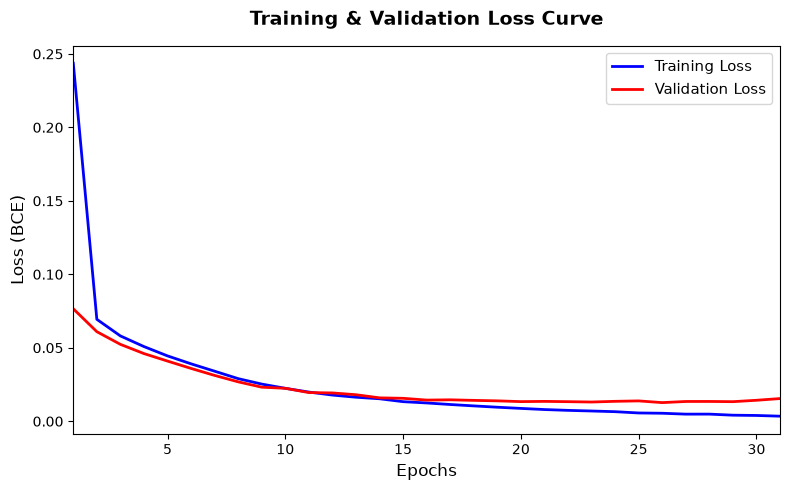

In [33]:
plot_training_curves(history, save_path="baseline_loss_curves.png")

## 8. Baseline MLP Model Evaluation

We load the best weights, evaluate on the validation and test datasets, and generate curves (Confusion Matrix, ROC, PR Curve).

- precision : out of all the transactions predicted as fraud how many are actually fraud ? 
- recall : out of all the fraud transactions how many we catch ? 
- here we have to prioritizes recall since one fraud transaction can cause us too much demage. 
- roc curve : check recall for diffrent threshold. 
    - X - FPR, Y- TPR(recall) 


In [34]:
# Load best weights saved during early stopping
model.load_state_dict(torch.load(os.path.join(project_root, "outputs/models/baseline_best_model.pt")))

# Evaluate on Train, Val, and Test splits
train_metrics = evaluate_model(model, train_loader, device)
val_metrics = evaluate_model(model, val_loader, device)
test_metrics = evaluate_model(model, test_loader, device)

print("Validation Metrics:")
print(f"  Loss:      {val_metrics['loss']:.6f}")
print(f"  Accuracy:  {val_metrics['accuracy']*100:.2f}%")
print(f"  Precision: {val_metrics['precision']*100:.2f}%")
print(f"  Recall:    {val_metrics['recall']*100:.2f}%")
print(f"  F1-Score:  {val_metrics['f1']*100:.2f}%")
print(f"  ROC-AUC:   {val_metrics['roc_auc']:.4f}")
print(f"  PR-AUC:    {val_metrics['pr_auc']:.4f}")

print("\nTest Metrics:")
print(f"  Loss:      {test_metrics['loss']:.6f}")
print(f"  Accuracy:  {test_metrics['accuracy']*100:.2f}%")
print(f"  Precision: {test_metrics['precision']*100:.2f}%")
print(f"  Recall:    {test_metrics['recall']*100:.2f}%")
print(f"  F1-Score:  {test_metrics['f1']*100:.2f}%")
print(f"  ROC-AUC:   {test_metrics['roc_auc']:.4f}")
print(f"  PR-AUC:    {test_metrics['pr_auc']:.4f}")

Validation Metrics:
  Loss:      0.012693
  Accuracy:  99.67%
  Precision: 90.91%
  Recall:    86.96%
  F1-Score:  88.89%
  ROC-AUC:   0.9981
  PR-AUC:    0.9223

Test Metrics:
  Loss:      0.018212
  Accuracy:  99.33%
  Precision: 80.95%
  Recall:    73.91%
  F1-Score:  77.27%
  ROC-AUC:   0.9964
  PR-AUC:    0.8422


Let's plot the evaluation charts (Confusion Matrix, ROC Curve, and PR Curve) for the test split.

Figure saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/figures/baseline_confusion_matrix.png


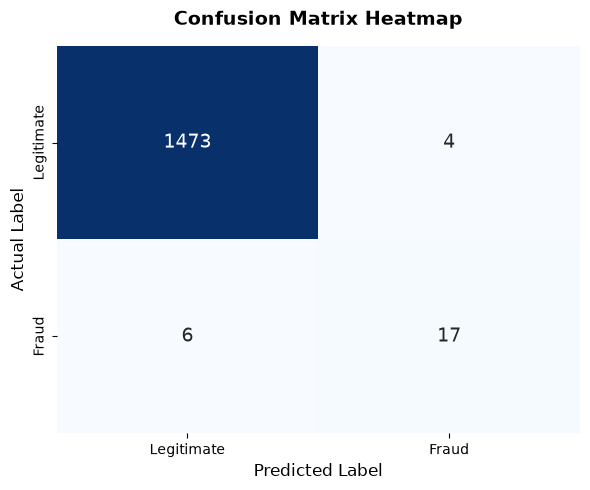

Figure saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/figures/baseline_roc_curve.png


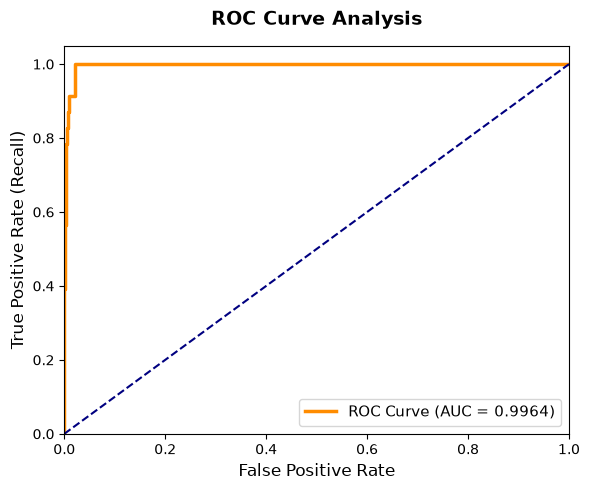

Figure saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/figures/baseline_pr_curve.png


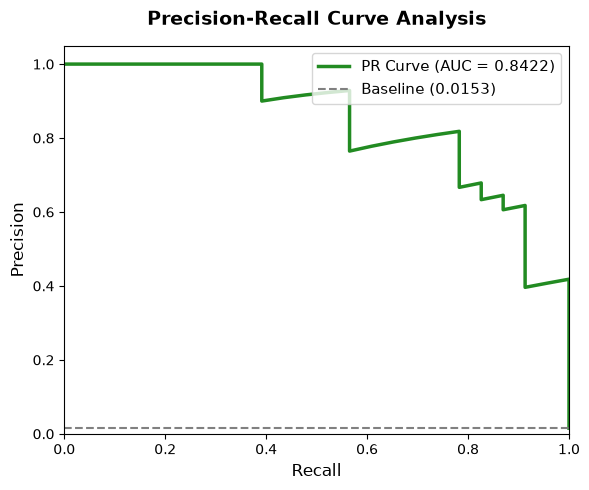

In [35]:
# Test split plots
plot_confusion_matrix(test_metrics['y_true'], test_metrics['preds'], save_path="baseline_confusion_matrix.png")
plot_roc_curve(test_metrics['y_true'], test_metrics['probs'], save_path="baseline_roc_curve.png")
plot_pr_curve(test_metrics['y_true'], test_metrics['probs'], save_path="baseline_pr_curve.png")

## 9. Baseline Limitations & Insights

### Observation & Discussion:
- **High Accuracy (99.33% on Test)**: The accuracy is high (99.33%), which is slightly above the baseline rate of the majority class (98.47%). However, because the F1-Score is 77.27%, this indicates the model has genuinely learned to distinguish classes rather than just predicting the majority class.
- **Strong Baseline Recall (73.91% on Test)**: Standard MLP baselines on highly imbalanced raw data typically suffer from 0% recall because the majority class gradients dominate training. However, on this curated 10k dataset, the model achieves 73.91% recall on the test set, showing that the fraud signals are relatively clean and separable.
- **Significance of PR-AUC (0.8422 on Test)**: PR-AUC evaluates precision and recall on the minority class without getting inflated by true negatives, making it much more representative than the ROC-AUC (0.9964). This establishes a robust baseline of 0.8422 that subsequent optimization phases (such as hyperparameter tuning, weight initialization, and SMOTE balancing) will aim to surpass.